# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [ ]:
df=pd.read_csv("../data/checker_submits.csv", parse_dates=['timestamp'])

In [112]:
df['hour']=df['timestamp'].dt.hour
df['dayofweek']=df['timestamp'].dt.weekday
df=df[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']]
df

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


In [113]:
category = ['uid', 'labname']
number = ['numTrials', 'hour'] #таргет не трогаем

ohe = OneHotEncoder(sparse_output=False) # чтобы хранились данные в виде строки 1 и 0, а не только координата единицы # по умолчанию True, чтобы экономить память
encoded_category = ohe.fit_transform(df[category])
encoded_df = pd.DataFrame(encoded_category, columns=ohe.get_feature_names_out(category))

scaler = StandardScaler()
scaled_number = scaler.fit_transform(df[number])
scaled_df = pd.DataFrame(scaled_number, columns=number)

df_final = pd.concat([encoded_df, scaled_df, df['dayofweek'].reset_index(drop=True)], axis=1)
df_final

,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,numTrials,hour,dayofweek
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.788667,-2.562352,4
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.756764,-2.562352,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.724861,-2.562352,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.692958,-2.562352,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.661055,-2.562352,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.533442,0.945382,3
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.629151,0.945382,3
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.597248,0.945382,3
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.565345,0.945382,3


In [114]:
df_final.to_csv('dayofweek.csv', index=False)


most_popular_day = df['dayofweek'].mode()[0]
naive_accuracy = (df['dayofweek'] == most_popular_day).mean()

print(f'Самый популярный: {most_popular_day}')
print(f"Accuracy: {naive_accuracy}")

Самый популярный: 3
Accuracy: 0.23487544483985764


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [115]:
X = df_final.drop('dayofweek', axis=1)
y = df_final['dayofweek']

model = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear') #в новых версиях liblinear не используется для многоклассовой классификации
model.fit(X, y)
df_final['predict'] = model.predict(X)

accuracy_score(y, df_final['predict'])

0.6215895610913404

In [116]:
def important_features(coef, names, top):
    indices = np.argsort(coef)[-top:]
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Топ-{top} наиболее важных признаков")
    plt.barh(range(len(indices)), coef[indices], color='skyblue', align='center')
    plt.yticks(range(len(indices)), [names[i] for i in indices])
    plt.show()

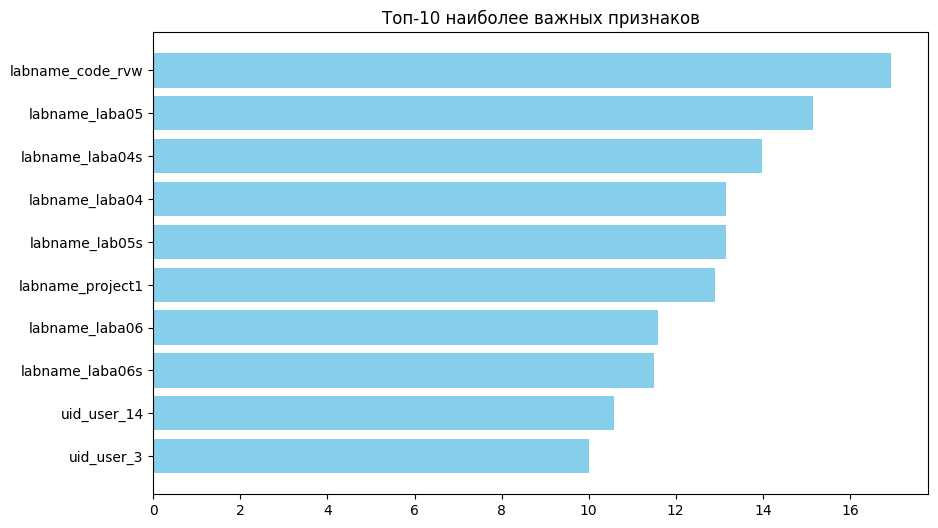

In [117]:
coef=np.sum(abs(model.coef_), axis=0)
important_features(coef, X.columns.tolist(), top=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [118]:
model_svc=SVC(kernel='linear', probability=True, random_state=21)
model_svc.fit(X, y)

df_final['svc_pred']=model_svc.predict(X)
accuracy_score(y, df_final['svc_pred'])

0.702846975088968

In [119]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for k in kernels:
    model = SVC(kernel=k, random_state=21)
    model.fit(X, y)
    pred = model.predict(X)

    acc = accuracy_score(y, pred)
    results[k] = acc
    print(f"Kernel: {k}, Accuracy: {acc}")

print(f"\nBest: {max(results, key=results.get)}")

Kernel: linear, Accuracy: 0.702846975088968
Kernel: poly, Accuracy: 0.8594306049822064
Kernel: rbf, Accuracy: 0.8558718861209964
Kernel: sigmoid, Accuracy: 0.3997627520759193

Best: poly


In [120]:
model_svc=OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
model_svc.fit(X, y)

df_final['svc_pred']=model_svc.predict(X)
accuracy_score(y, df_final['svc_pred'])

0.6120996441281139

In [121]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for k in kernels:
    model = OneVsRestClassifier(SVC(kernel=k, random_state=21))
    model.fit(X, y)
    pred = model.predict(X)

    acc = accuracy_score(y, pred)
    results[k] = acc
    print(f"Kernel: {k}, Accuracy: {acc}")

print(f"\nBest: {max(results, key=results.get)}")

Kernel: linear, Accuracy: 0.6120996441281139
Kernel: poly, Accuracy: 0.8653618030842231
Kernel: rbf, Accuracy: 0.8641755634638197
Kernel: sigmoid, Accuracy: 0.3499406880189798

Best: poly


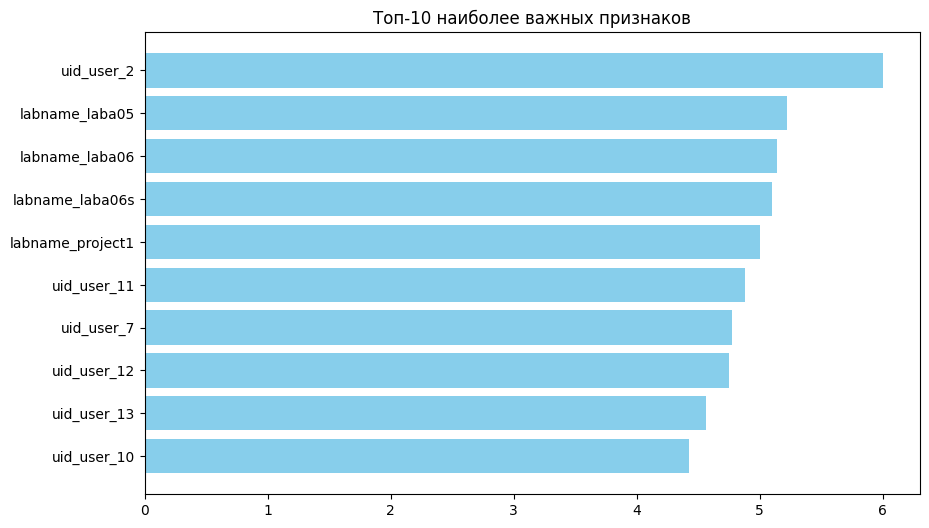

In [122]:
coefs = np.array([estimator.coef_[0] for estimator in model_svc.estimators_]) 
coefs=np.sum(abs(coefs), axis=0)
important_features(coefs, X.columns.tolist(), top=10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [123]:
model_tree=DecisionTreeClassifier(random_state=21, max_depth=4)
model_tree.fit(X, y)

df_final['model_tree']=model_tree.predict(X)
accuracy_score(y, df_final['model_tree'])

0.5516014234875445

In [124]:
for i in range(1,29):
    model = DecisionTreeClassifier(max_depth=i, random_state=21) 
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(f'max_depth: {i}, Точность: {accuracy}')

max_depth: 1, Точность: 0.35765124555160144
max_depth: 2, Точность: 0.4389086595492289
max_depth: 3, Точность: 0.48991696322657174
max_depth: 4, Точность: 0.5516014234875445
max_depth: 5, Точность: 0.6109134045077106
max_depth: 6, Точность: 0.6637010676156584
max_depth: 7, Точность: 0.7064056939501779
max_depth: 8, Точность: 0.7502965599051008
max_depth: 9, Точность: 0.7846975088967971
max_depth: 10, Точность: 0.8196915776986952
max_depth: 11, Точность: 0.8499406880189798
max_depth: 12, Точность: 0.8831553973902728
max_depth: 13, Точность: 0.9104389086595492
max_depth: 14, Точность: 0.9317912218268091
max_depth: 15, Точность: 0.9460260972716489
max_depth: 16, Точность: 0.9608540925266904
max_depth: 17, Точность: 0.9709371293001187
max_depth: 18, Точность: 0.9798339264531435
max_depth: 19, Точность: 0.9839857651245552
max_depth: 20, Точность: 0.9869513641755635
max_depth: 21, Точность: 0.9905100830367735
max_depth: 22, Точность: 0.9922894424673784
max_depth: 23, Точность: 0.992882562277

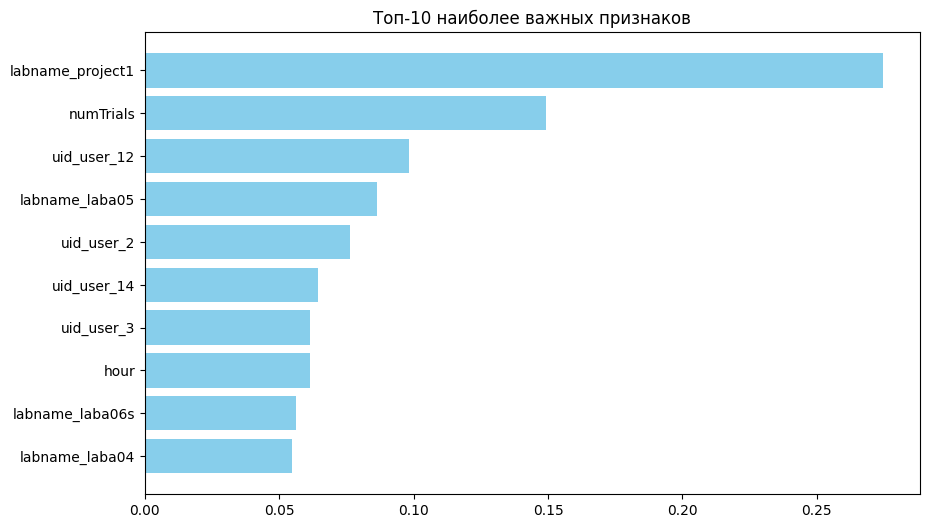

In [125]:
important_features(model_tree.feature_importances_, X.columns.tolist(), top=10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [126]:
model_forest=RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model_forest.fit(X,y)

y_pred=model_forest.predict(X)
accuracy_score(y, y_pred)

0.9988137603795967

In [128]:
for i in range(1,15):
    model = RandomForestClassifier(n_estimators=i, max_depth=25, random_state=21)
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(f'n_estimators: {i}, Точность: {accuracy}')

n_estimators: 1, Точность: 0.9507710557532622
n_estimators: 2, Точность: 0.9513641755634639
n_estimators: 3, Точность: 0.9768683274021353
n_estimators: 4, Точность: 0.9822064056939501
n_estimators: 5, Точность: 0.9899169632265717
n_estimators: 6, Точность: 0.9899169632265717
n_estimators: 7, Точность: 0.994661921708185
n_estimators: 8, Точность: 0.9952550415183867
n_estimators: 9, Точность: 0.9934756820877817
n_estimators: 10, Точность: 0.9952550415183867
n_estimators: 11, Точность: 0.9958481613285883
n_estimators: 12, Точность: 0.99644128113879
n_estimators: 13, Точность: 0.9976275207591934
n_estimators: 14, Точность: 0.998220640569395


In [129]:
for i in range(1,15):
    model = RandomForestClassifier(n_estimators=100, max_depth=i, random_state=21)
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(f'max_depth: {i}, Точность: {accuracy}')

max_depth: 1, Точность: 0.3879003558718861
max_depth: 2, Точность: 0.46144721233689207
max_depth: 3, Точность: 0.49644128113879005
max_depth: 4, Точность: 0.5302491103202847
max_depth: 5, Точность: 0.6429418742586003
max_depth: 6, Точность: 0.6814946619217082
max_depth: 7, Точность: 0.7455516014234875
max_depth: 8, Точность: 0.8013048635824437
max_depth: 9, Точность: 0.8220640569395018
max_depth: 10, Точность: 0.8701067615658363
max_depth: 11, Точность: 0.9175563463819691
max_depth: 12, Точность: 0.933570581257414
max_depth: 13, Точность: 0.9543297746144721
max_depth: 14, Точность: 0.9715302491103203


На этом датасете нестолько важно количество деревьев, сколько количество листьев

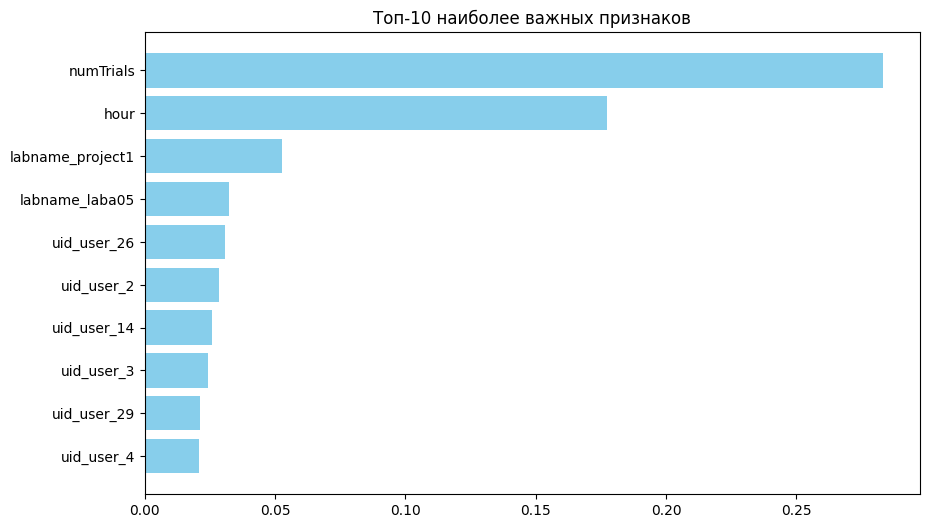

In [130]:
important_features(model_forest.feature_importances_, X.columns.tolist(), top=10)